# 03 - Clean and Process Data

## Objective

Build the reusable analysis tables from the audited raw data.

This notebook:
- standardizes timestamps and basic data types.
- defines the primary observation window.
- converts document events into document-level clearance outcomes.
- builds a one-row-per-captain analysis table.
- joins approval and activation outcomes.
- derives onboarding and activation timing fields.
- validates and saves the processed dataset.

The raw CSV files are read only; they are not modified.

In [1]:
import pandas as pd
import numpy as np

## 1. Load the raw datasets

The seven source tables cover the captain lifecycle, document verification, activation, nudges, and airport operations.

In [2]:
captains = pd.read_csv("../data/captains.csv")
doc_events = pd.read_csv("../data/doc_events.csv")
approvals = pd.read_csv("../data/approvals.csv")
activation = pd.read_csv("../data/activation.csv")
nudges = pd.read_csv("../data/nudges.csv")
airport_hourly = pd.read_csv("../data/airport_hourly.csv")
airport_trips = pd.read_csv("../data/airport_trips.csv")

print("Raw datasets loaded.")

Raw datasets loaded.


In [3]:
dataset_shapes = pd.DataFrame({
    "dataset": [
        "captains", "doc_events", "approvals", "activation",
        "nudges", "airport_hourly", "airport_trips"
    ],
    "rows": [
        len(captains), len(doc_events), len(approvals), len(activation),
        len(nudges), len(airport_hourly), len(airport_trips)
    ],
    "columns": [
        len(captains.columns), len(doc_events.columns), len(approvals.columns),
        len(activation.columns), len(nudges.columns),
        len(airport_hourly.columns), len(airport_trips.columns)
    ]
})

display(dataset_shapes)

,dataset,rows,columns
0,captains,25000,9
1,doc_events,186282,7
2,approvals,25000,5
3,activation,4206,5
4,nudges,16314,6
5,airport_hourly,10248,9
6,airport_trips,60000,9


## 2. Standardize timestamps

All event timestamps are converted to pandas datetime values so that elapsed-time calculations and cutoff checks are consistent.

In [4]:
tables = {
    "captains": captains,
    "doc_events": doc_events,
    "approvals": approvals,
    "activation": activation,
    "nudges": nudges,
    "airport_hourly": airport_hourly,
    "airport_trips": airport_trips,
}

In [5]:
timestamp_columns = {
    "captains": ["signup_ts"],
    "doc_events": ["event_ts"],
    "approvals": ["decision_ts"],
    "activation": ["first_order_ts"],
    "nudges": ["sent_ts"],
    "airport_hourly": ["hour_ts"],
    "airport_trips": ["request_ts"],
}

In [6]:
for table_name, columns in timestamp_columns.items():
    table = tables[table_name]

    for column in columns:
        table[column] = pd.to_datetime(
            table[column],
            errors="coerce"
        )

In [7]:
timestamp_check = pd.DataFrame([
    {
        "dataset": table_name,
        "column": column,
        "dtype": str(tables[table_name][column].dtype),
        "missing": int(tables[table_name][column].isna().sum())
    }
    for table_name, columns in timestamp_columns.items()
    for column in columns
])

display(timestamp_check)

,dataset,column,dtype,missing
0,captains,signup_ts,datetime64[ns],0
1,doc_events,event_ts,datetime64[ns],0
2,approvals,decision_ts,datetime64[ns],20359
3,activation,first_order_ts,datetime64[ns],102
4,nudges,sent_ts,datetime64[ns],0
5,airport_hourly,hour_ts,datetime64[ns],0
6,airport_trips,request_ts,datetime64[ns],0


## 3. Define the observation window

The source data runs through **June 30, 2026**. Recent signups may not have had enough time to complete onboarding by the extraction date.

For the primary onboarding funnel, this notebook flags captains with at least **14 days of observable time**. This is a cohort eligibility flag, not a deletion rule: all captains remain in `captain_base`.

In [8]:
DATA_CUTOFF = pd.Timestamp("2026-06-30 23:59:59")
MIN_OBSERVATION_DAYS = 14

In [9]:
captains["days_observed"] = (
    DATA_CUTOFF - captains["signup_ts"]
).dt.total_seconds() / (24 * 60 * 60)

In [10]:
captains["eligible_for_funnel"] = (
    captains["days_observed"] >= MIN_OBSERVATION_DAYS
)

In [11]:
observation_summary = pd.Series({
    "total_captains": len(captains),
    "funnel_eligible": int(captains["eligible_for_funnel"].sum()),
    "right_censored": int((~captains["eligible_for_funnel"]).sum()),
})

display(observation_summary.to_frame("count"))

,count
total_captains,25000
funnel_eligible,22757
right_censored,2243


In [12]:
captains["days_observed"].describe()

count    25000.000000
mean        85.546792
std         52.144111
min          0.085405
25%         39.534190
50%         83.342002
75%        130.130891
max        180.744433
Name: days_observed, dtype: float64

### Observation Window: Mature vs Right-Censored Captains

The primary funnel requires at least 14 days of observable time after signup. Recent signups are therefore flagged as potentially right-censored rather than treated as onboarding failures.

This graph shows how the full signup population is divided between funnel-eligible captains and recently signed-up captains who have not yet had the full observation window.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

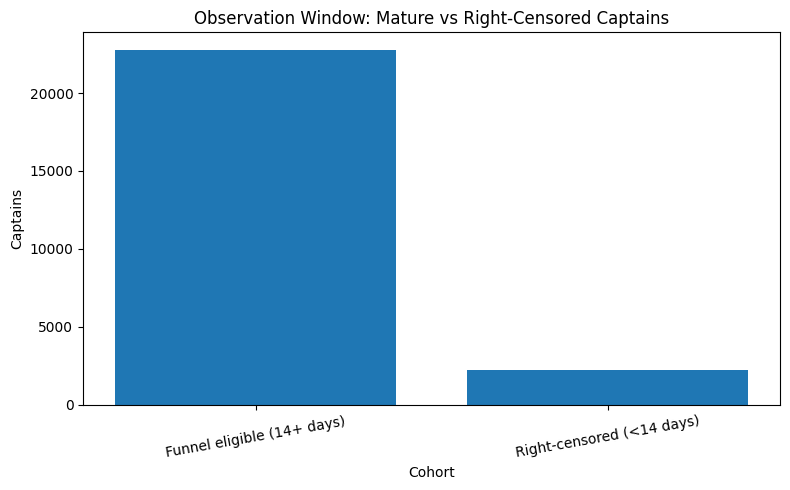

In [13]:
observation_plot = pd.Series({
    "Funnel eligible (14+ days)": int(captains["eligible_for_funnel"].sum()),
    "Right-censored (<14 days)": int((~captains["eligible_for_funnel"]).sum()),
})

plt.figure(figsize=(8, 5))

plt.bar(
    observation_plot.index,
    observation_plot.values
)

plt.xlabel("Cohort")
plt.ylabel("Captains")
plt.title("Observation Window: Mature vs Right-Censored Captains")
plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

## 4. Process document events

`doc_events` contains multiple events for each captain-document combination.

For downstream funnel analysis, the event history is reduced to one row per **captain × document type**. A document is marked as cleared if it has at least one `verification_pass` event.

`attempts` uses the maximum recorded `attempt_no`, while the event flags preserve whether an upload, pass, or failure occurred at any point.

In [14]:
doc_summary = (
    doc_events
    .groupby(["captain_id", "doc_type"], as_index=False)
    .agg(
        attempts=("attempt_no", "max"),
        upload_success=("event_type", lambda x: (x == "upload_success").any()),
        verification_pass=("event_type", lambda x: (x == "verification_pass").any()),
        verification_fail=("event_type", lambda x: (x == "verification_fail").any()),
    )
)

In [15]:
first_pass = (
    doc_events.loc[
        doc_events["event_type"].eq("verification_pass"),
        ["captain_id", "doc_type", "event_ts"]
    ]
    .groupby(["captain_id", "doc_type"], as_index=False)["event_ts"]
    .min()
    .rename(columns={"event_ts": "first_pass_ts"})
)

In [16]:
doc_summary = doc_summary.merge(
    first_pass,
    on=["captain_id", "doc_type"],
    how="left",
    validate="one_to_one",
)

In [17]:
display(doc_summary.head())
print("Document-level rows:", len(doc_summary))

,captain_id,doc_type,attempts,upload_success,verification_pass,verification_fail,first_pass_ts
0,CPT100000,AADHAAR,1,True,True,False,2026-05-04 12:16:11.389574146
1,CPT100000,DL,1,True,True,False,2026-05-02 22:37:15.678999608
2,CPT100000,FITNESS,2,True,False,True,NaT
3,CPT100000,PERMIT,1,True,True,False,2026-05-05 14:52:12.185964306
4,CPT100000,RC,1,True,True,False,2026-05-03 17:48:59.486740931


Document-level rows: 81173


In [18]:
doc_summary["verification_fail_without_pass"] = (
    doc_summary["verification_fail"] & ~doc_summary["verification_pass"]
)

In [19]:
display(
    doc_summary["doc_type"].value_counts().rename_axis("doc_type").to_frame("captain_document_rows")
)

,captain_document_rows
doc_type,
DL,23303
RC,19248
AADHAAR,14665
FITNESS,9248
PERMIT,9213
INSURANCE,5496


In [20]:
print(
    "Captain-document records with a failure but no eventual pass:",
    int(doc_summary["verification_fail_without_pass"].sum())
)

Captain-document records with a failure but no eventual pass: 7729


## 5. Create captain-level document features

The funnel is evaluated at captain level, so document outcomes are pivoted into clearance indicators.

Missing document rows are treated as **not cleared** in these boolean features. This does not mean the document failed; it means there is no recorded successful verification event for that captain-document pair.

In [21]:
doc_cleared = (
    doc_summary
    .pivot(
        index="captain_id",
        columns="doc_type",
        values="verification_pass"
    )
    .reset_index()
)

In [22]:
doc_cleared.columns.name = None

doc_cleared = doc_cleared.rename(columns={
    "DL": "DL_cleared",
    "RC": "RC_cleared",
    "AADHAAR": "AADHAAR_cleared",
    "PERMIT": "PERMIT_cleared",
    "FITNESS": "FITNESS_cleared",
    "INSURANCE": "INSURANCE_cleared",
})

In [23]:
doc_columns = [
    "DL_cleared",
    "RC_cleared",
    "AADHAAR_cleared",
    "PERMIT_cleared",
    "FITNESS_cleared",
    "INSURANCE_cleared",
]

In [24]:
for column in doc_columns:
    doc_cleared[column] = (
        doc_cleared[column]
        .astype("boolean")
        .fillna(False)
    )

display(doc_cleared.head())

,captain_id,AADHAAR_cleared,DL_cleared,FITNESS_cleared,INSURANCE_cleared,PERMIT_cleared,RC_cleared
0,CPT100000,True,True,False,False,True,True
1,CPT100001,False,True,False,False,False,False
2,CPT100002,True,True,True,True,True,True
3,CPT100003,False,True,False,False,False,False
4,CPT100004,True,True,True,False,False,True


## 6. Build the captain-level analysis table

`captains` is the signup-level universe, so it remains the base table throughout the joins.

This prevents captains with no document events, no approval decision, or no activation record from disappearing from the analysis.

In [25]:
captain_base = captains.merge(
    doc_cleared,
    on="captain_id",
    how="left",
    validate="one_to_one",
)

In [26]:
for column in doc_columns:
    captain_base[column] = (
        captain_base[column]
        .astype("boolean")
        .fillna(False)
    )

print("Rows:", len(captain_base))
print("Unique captain IDs:", captain_base["captain_id"].nunique())

Rows: 25000
Unique captain IDs: 25000


In [27]:
display(
    captain_base[doc_columns]
    .sum()
    .rename("captains_with_passed_document")
    .to_frame()
)

,captains_with_passed_document
DL_cleared,21954
RC_cleared,15852
AADHAAR_cleared,14095
PERMIT_cleared,8468
FITNESS_cleared,8241
INSURANCE_cleared,4664


### Document Clearance Overview

The raw document-event history has been reduced to captain-level clearance indicators. This graph shows how many captains have at least one successful verification pass for each document.

The metric represents observed successful verification, not proof that a missing document failed.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

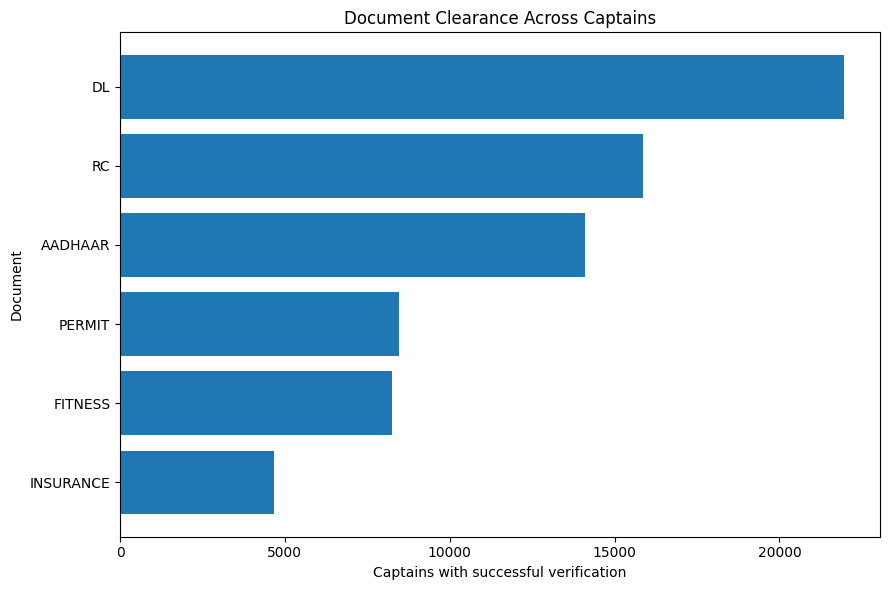

In [28]:
document_clearance = (
    captain_base[doc_columns]
    .sum()
    .sort_values(ascending=True)
)

document_clearance.index = (
    document_clearance.index
    .str.replace("_cleared", "", regex=False)
)

plt.figure(figsize=(9, 6))

plt.barh(
    document_clearance.index,
    document_clearance.values
)

plt.xlabel("Captains with successful verification")
plt.ylabel("Document")
plt.title("Document Clearance Across Captains")

plt.tight_layout()
plt.show()

## 7. Add approval outcomes

The approval table contains the final onboarding outcome and the last stage reached.

It is joined one-to-one on `captain_id`, while retaining the full signup population.

In [29]:
approval_columns = [
    "captain_id",
    "decision_ts",
    "final_status",
    "last_stage_reached",
    "docs_cleared",
]

In [30]:
captain_base = captain_base.merge(
    approvals[approval_columns],
    on="captain_id",
    how="left",
    validate="one_to_one",
)

In [31]:
print("Rows after approval join:", len(captain_base))
print("Unique captain IDs:", captain_base["captain_id"].nunique())

Rows after approval join: 25000
Unique captain IDs: 25000


In [32]:
display(
    captain_base["final_status"]
    .value_counts(dropna=False)
    .rename_axis("final_status")
    .to_frame("captains")
)

,captains
final_status,
dropped_in_docs,19062
approved,4206
in_progress,1297
rejected,435


In [33]:
print("Raw captains:")
display(captains["app_language"].value_counts(dropna=False).sort_index())

print("\nFinal captain_base:")
display(captain_base["app_language"].value_counts(dropna=False).sort_index())

print(
    "\nUnique categories preserved:",
    set(captains["app_language"].dropna().unique())
    == set(captain_base["app_language"].dropna().unique())
)

print(
    "Row count preserved:",
    len(captains) == len(captain_base)
)

Raw captains:


app_language
en    4952
hi    4947
kn    5081
mr    4956
te    5064
Name: count, dtype: int64


Final captain_base:


app_language
en    4952
hi    4947
kn    5081
mr    4956
te    5064
Name: count, dtype: int64


Unique categories preserved: True
Row count preserved: True


## 8. Add activation outcomes

`activation` contains post-approval activity for approved captains.

A left join keeps non-approved and non-activated captains in the analysis table. A missing `first_order_ts` therefore means there is no recorded first order in the activation data; it is not converted to zero.

In [34]:
activation_columns = [
    "captain_id",
    "first_order_ts",
    "orders_d7",
    "orders_d30",
    "online_hours_d30",
]

In [35]:
captain_base = captain_base.merge(
    activation[activation_columns],
    on="captain_id",
    how="left",
    validate="one_to_one",
)

In [36]:
print("Rows after activation join:", len(captain_base))
print("Unique captain IDs:", captain_base["captain_id"].nunique())

Rows after activation join: 25000
Unique captain IDs: 25000


In [37]:
activation_summary = pd.Series({
    "approved captains": int(captain_base["final_status"].eq("approved").sum()),
    "with first order": int(captain_base["first_order_ts"].notna().sum()),
    "without first order": int(captain_base["first_order_ts"].isna().sum()),
})

In [38]:
display(activation_summary.to_frame("count"))

,count
approved captains,4206
with first order,4104
without first order,20896


### Approval vs First-Order Activation

Approval and activation are distinct lifecycle outcomes. An approved captain may still have no recorded first order.

This graph makes that distinction explicit by comparing the number of approved captains with captains who have a recorded first order.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

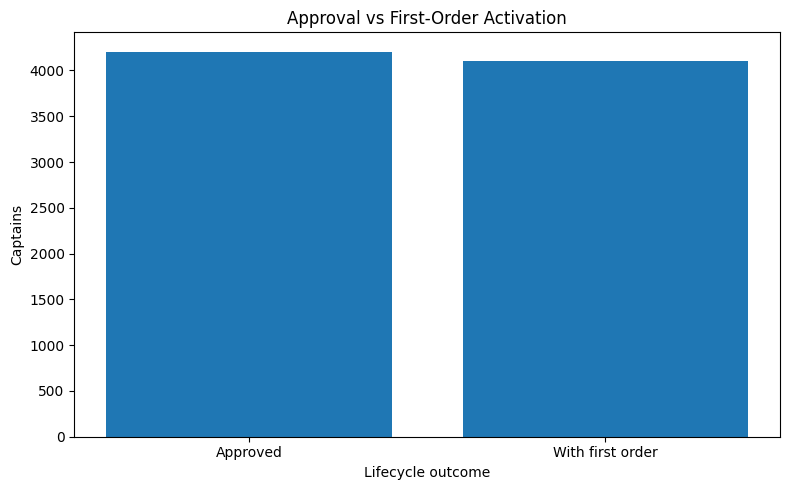

In [39]:
activation_plot = pd.Series({
    "Approved": int(captain_base["final_status"].eq("approved").sum()),
    "With first order": int(captain_base["first_order_ts"].notna().sum()),
})

plt.figure(figsize=(8, 5))

plt.bar(
    activation_plot.index,
    activation_plot.values
)

plt.xlabel("Lifecycle outcome")
plt.ylabel("Captains")
plt.title("Approval vs First-Order Activation")

plt.tight_layout()
plt.show()

## 9. Derive lifecycle durations

Two reusable timing fields are created:

- `signup_to_approval_days`: signup → approval decision
- `approval_to_first_order_days`: approval decision → first completed order

Missing timestamps naturally produce missing durations.

In [40]:
captain_base["signup_to_approval_days"] = (
    captain_base["decision_ts"] - captain_base["signup_ts"]
).dt.total_seconds() / (24 * 60 * 60)

In [41]:
captain_base["approval_to_first_order_days"] = (
    captain_base["first_order_ts"] - captain_base["decision_ts"]
).dt.total_seconds() / (24 * 60 * 60)

In [42]:
duration_summary = captain_base[
    ["signup_to_approval_days", "approval_to_first_order_days"]
].describe()

In [43]:
display(duration_summary)

,signup_to_approval_days,approval_to_first_order_days
count,4641.000000,4104.000000
mean,6.429790,1.714744
std,1.547602,1.365636
min,2.542293,0.001303
25%,5.341806,0.721890
50%,6.313038,1.374499
75%,7.387370,2.364522
max,14.109059,11.068693


### Lifecycle Duration Distributions

The processed captain table now contains two reusable lifecycle duration measures:

- signup → approval decision
- approval decision → first completed order

The distributions provide a basic view of how long these lifecycle transitions take. Missing timestamps remain missing rather than being converted into artificial zero-duration values.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

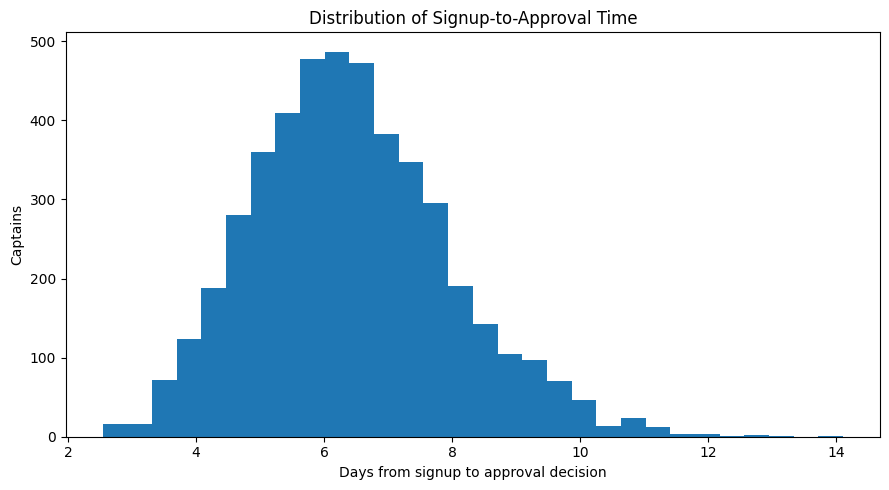

In [44]:
plt.figure(figsize=(9, 5))

plt.hist(
    captain_base["signup_to_approval_days"].dropna(),
    bins=30
)

plt.xlabel("Days from signup to approval decision")
plt.ylabel("Captains")
plt.title("Distribution of Signup-to-Approval Time")

plt.tight_layout()
plt.show()

In [45]:
display(
    captain_base[
        [
            "captain_id",
            "signup_to_approval_days",
            "approval_to_first_order_days"
        ]
    ].dropna().head(5)
)

,captain_id,signup_to_approval_days,approval_to_first_order_days
0,CPT104359,5.085981,5.166733
5,CPT105916,6.088919,0.775105
15,CPT115782,6.529279,2.557503
18,CPT124093,6.835224,1.464606
31,CPT101207,6.382102,1.918154


In [46]:
duration_checks = pd.Series({
    "negative signup-to-approval durations": int(
        (captain_base["signup_to_approval_days"] < 0).sum()
    ),
    "negative approval-to-first-order durations": int(
        (captain_base["approval_to_first_order_days"] < 0).sum()
    ),
})

In [47]:
display(duration_checks.to_frame("count"))

,count
negative signup-to-approval durations,0
negative approval-to-first-order durations,0


## 10. Final integrity checks

Before saving, verify that the processed table still has the intended one-row-per-captain grain and that the key lifecycle joins did not create duplicate rows.

In [48]:
final_checks = pd.Series({
    "rows": len(captain_base),
    "unique captain IDs": captain_base["captain_id"].nunique(),
    "duplicate captain IDs": int(captain_base["captain_id"].duplicated().sum()),
    "negative signup-to-approval": int(
        (captain_base["signup_to_approval_days"] < 0).sum()
    ),
    "negative approval-to-first-order": int(
        (captain_base["approval_to_first_order_days"] < 0).sum()
    ),
})

In [49]:
display(final_checks.to_frame("value"))

,value
rows,25000
unique captain IDs,25000
duplicate captain IDs,0
negative signup-to-approval,0
negative approval-to-first-order,0


In [50]:
missing_summary = (
    captain_base.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing")
    .to_frame()
)

In [51]:
display(missing_summary[missing_summary["missing"] > 0].head(15))

,missing
online_hours_d30,21628
orders_d30,21628
orders_d7,20981
approval_to_first_order_days,20896
first_order_ts,20896
signup_to_approval_days,20359
decision_ts,20359
last_stage_reached,4393


## 11. Save the processed captain dataset

The processed captain-level table is saved as an intermediate dataset for the downstream funnel, campaign, and activation analyses.

In [52]:
OUTPUT_PATH = "../data/captain_base.csv"
captain_base.to_csv(OUTPUT_PATH, index=False)

In [53]:
print(f"Saved: {OUTPUT_PATH}")
print(f"Shape: {captain_base.shape}")

Saved: ../data/captain_base.csv
Shape: (25000, 27)


# Conclusion

## 1. Purpose of this notebook

Notebook 3 transforms the audited raw datasets into a reusable analytical dataset for the downstream onboarding, campaign, and activation analysis.

The main objective was not to remove unusual records, but to convert event-level information into meaningful captain-level features while preserving the original signup population.

The resulting dataset is designed around a **one-row-per-captain** grain.

---

## 2. Observation window and cohort maturity

The source data has an extraction cutoff of **June 30, 2026**.

Because recent signups may not have had enough time to complete onboarding, the primary funnel uses a minimum observation period of **14 days**.

The notebook therefore creates:

* `days_observed` — number of days between signup and the extraction cutoff.
* `eligible_for_funnel` — whether the captain had at least 14 days of observable time.

Importantly, recent signups are **not deleted** from the dataset.

The full population contains **25,000 captains**. Of these:

* **22,757 captains** are eligible for the primary funnel.
* **2,243 captains** are treated as potentially right-censored because they have less than 14 days of observation.

This allows downstream funnel analysis to use a mature cohort without incorrectly treating recent signups as onboarding failures.

---

## 3. Document events were converted into analytical outcomes

The raw `doc_events` table contains **186,282 event records**.

Because a single captain can generate multiple events for the same document through uploads, failures, retries, and verification outcomes, the raw event table is not directly suitable for captain-level funnel analysis.

The notebook therefore aggregates the event history to one row per:

**captain × document type**

For each captain-document combination, the processed data records:

* maximum attempt number;
* whether an upload success occurred;
* whether a verification pass occurred;
* whether a verification failure occurred; and
* the timestamp of the first successful verification pass.

A document is considered cleared when at least one `verification_pass` event is observed.

A useful distinction is preserved between:

* a document that failed and later passed; and
* a document that failed without any eventual pass.

This prevents an intermediate failed attempt from being incorrectly interpreted as the captain's final document outcome.

---

## 4. Document outcomes were converted into captain-level features

The document-level summary is then pivoted into captain-level clearance indicators:

* `DL_cleared`
* `RC_cleared`
* `AADHAAR_cleared`
* `PERMIT_cleared`
* `FITNESS_cleared`
* `INSURANCE_cleared`

Missing document rows are represented as `False` in these clearance features because no successful verification pass was observed.

This should **not** be interpreted as proof that the document failed. It means only that the processed dataset has no recorded successful verification event for that captain-document combination.

This distinction will be important when interpreting funnel drop-offs in the next notebook.

---

## 5. A captain-level analytical table was created

The `captains` table remains the base table because it represents the complete signup universe.

The processed document features are left-joined to this table using `captain_id`.

Approval information is then added, including:

* `decision_ts`
* `final_status`
* `last_stage_reached`
* `docs_cleared`

Activation information is subsequently added, including:

* `first_order_ts`
* `orders_d7`
* `orders_d30`
* `online_hours_d30`

All joins are validated as one-to-one so that the processing pipeline does not accidentally multiply captain rows.

The resulting analytical table therefore retains captains even when they have:

* no successful document verification;
* no approval decision; or
* no activation record.

This preserves the correct denominator for downstream analysis.

---

## 6. Approval and activation are kept as separate outcomes

The processed table makes an important distinction between onboarding completion and actual activation.

There are **4,206 approved captains** in the processed population.

Of these, **4,104 captains have a recorded first order**, while **102 approved captains do not have a recorded first-order timestamp**.

Therefore:

**4,206 approved − 102 without first order = 4,104 with first order**

This demonstrates why approval should not automatically be treated as activation.

A captain can successfully complete onboarding and still fail to progress to the first completed order.

---

## 7. Lifecycle timing features were created

Two reusable duration measures were derived:

### Signup → Approval

`signup_to_approval_days`

This measures the elapsed time between the captain's signup and the approval decision.

The duration is available for **4,641 captains**, meaning 4,641 records contain the timestamps required to calculate this measure.

The value **4,641 is a count of non-missing duration observations, not 4,641 days**.

### Approval → First Order

`approval_to_first_order_days`

This measures the elapsed time between the approval decision and the first completed order.

The duration is available for **4,104 captains**.

This matches the number of approved captains with a recorded first order:

**4,206 approved − 102 without first order = 4,104**

Missing timestamps naturally produce missing duration values rather than artificial zero-duration values.

The final integrity checks confirm that no negative lifecycle durations were introduced.

---

## 8. Data integrity after processing

The final processed table retains the intended **one-row-per-captain** grain.

The processing pipeline checks:

* total row count;
* unique captain IDs;
* duplicate captain IDs;
* negative signup-to-approval durations; and
* negative approval-to-first-order durations.

The processed dataset therefore provides a controlled analytical layer between the audited raw data and the downstream analysis.

The raw CSV files remain unchanged.

---

## 9. What we now have

At the end of Notebook 3, the original event-heavy data has been transformed into a captain-level analytical representation containing:

```text
Captain attributes
        +
Observation-window flags
        +
DL clearance
        +
RC clearance
        +
Aadhaar clearance
        +
Permit clearance
        +
Fitness clearance
        +
Insurance clearance
        +
Approval outcome
        +
Approval timing
        +
First-order outcome
        +
Activation metrics
        +
Lifecycle durations
```

The key output is:

`captain_base.csv`

This becomes the main captain-level input for the downstream funnel, campaign, and activation analyses.

---

## 10. Key numerical takeaways

| Metric                                                   |       Count |
| -------------------------------------------------------- | ----------: |
| Total signups                                            |  **25,000** |
| Funnel-eligible signups                                  |  **22,757** |
| Potentially right-censored signups                       |   **2,243** |
| Raw document events                                      | **186,282** |
| Approved captains                                        |   **4,206** |
| Approved without first order                             |     **102** |
| Captains with first order                                |   **4,104** |
| Captains with calculable signup → approval duration      |   **4,641** |
| Captains with calculable approval → first-order duration |   **4,104** |

---

## 11. Handover to Notebook 4

Notebook 3 answers:

> **“How do we turn the raw lifecycle history into a reliable analytical table?”**

The answer is:

1. preserve the signup universe;
2. handle cohort maturity explicitly;
3. aggregate document events;
4. create captain-level document clearance features;
5. join approval and activation outcomes;
6. derive lifecycle timing measures; and
7. validate the resulting one-row-per-captain table.

We are now ready for the next question:

> **Where exactly are captains being lost in the onboarding funnel?**

Notebook 4 will use `captain_base.csv` to reconstruct the cumulative funnel:

**Signup → DL → RC → Aadhaar → Permit → Fitness → Insurance → Approval**

and quantify stage-level conversion, drop-off volume, and cumulative A2O.

That is where the data transformation from Notebook 3 becomes a business diagnosis.
